In [ ]:
%pip install kagglehub[pandas-datasets]
%pip install openpyxl #Instalando dependência para abrir .XLSX
%pip install matplotlib

In [105]:

import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import openpyxl as opn 


In [120]:
import numpy as np

Carregando diretamente do Kaggle

In [3]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = 'iFood.xlsx'

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "fayez7/ifood-marketing-campaigns",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("Primeiros dados:", df.head())

C:\Users\Support\AppData\Local\Temp\ipykernel_18800\314115443.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Primeiros dados:    Index  Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  \
0   1001   58138        0         0       58       635         88   
1   1002   46344        1         1       38        11          1   
2   1003   71613        0         0       26       426         49   
3   1004   26646        1         0       26        11          4   
4   1005   58293        1         0       94       173         43   

   MntMeatProducts  MntFishProducts  MntSweetProducts  ...  AcceptedCmp2  \
0              546              172                88  ...             0   
1                6                2                 1  ...             0   
2              127              111                21  ...             0   
3               20               10                 3  ...             0   
4              118               46                27  ...             0   

   AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  AcceptedCmpOverall  Complain  \
0             0             0     

In [187]:
df.isnull().sum()

Index                  0
Income                 0
Kidhome                0
Teenhome               0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntRegularProds        0
MntGoldProds           0
MntTotal               0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp1           0
AcceptedCmp2           0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmpOverall     0
Complain               0
Age                    0
Customer_Days          0
marital_status         0
education              0
AgeRange               0
IncomeMonth            0
cluster                0
MntTotal_>_1k          0
dtype: int64

In [144]:
# Identificar outliers em MntTotal usando IQR

Q1 = df['MntTotal'].quantile(0.25)
Q3 = df['MntTotal'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_mnttotal = df[
    (df['MntTotal'] < limite_inferior) |
    (df['MntTotal'] > limite_superior)
]

print(f"Limite inferior: {limite_inferior}")
print(f"Limite superior: {limite_superior}")
print(f"Quantidade de outliers: {len(outliers_mnttotal)}")

outliers_mnttotal[['Index', 'Age', 'Income', 'MntTotal']].sort_values(
    by='MntTotal',
    ascending=False
)

Limite inferior: -1306.0
Limite superior: 2326.0
Quantidade de outliers: 3


,Index,Age,Income,MntTotal
1467,2468,32,87679,2491
1159,2160,29,90638,2429
1547,2548,29,90638,2429


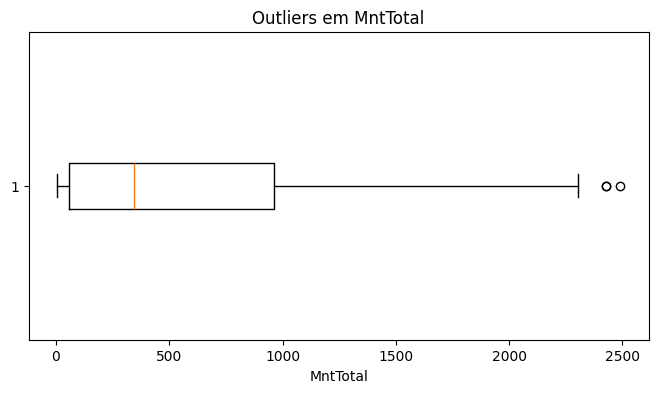

In [145]:
plt.figure(figsize=(8, 4))
plt.boxplot(df['MntTotal'], vert=False)
plt.title('Outliers em MntTotal')
plt.xlabel('MntTotal')
plt.show()

In [146]:
# Remover outliers da coluna MntTotal usando IQR

Q1 = df['MntTotal'].quantile(0.25)
Q3 = df['MntTotal'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df = df[
    (df['MntTotal'] >= limite_inferior) &
    (df['MntTotal'] <= limite_superior)
].copy()

print(f"Novo tamanho do df: {df.shape}")

Novo tamanho do df: (2202, 32)


In [147]:
#Selecionando algumas colunas para análise
pd.DataFrame(df, columns=['Index','Income','Age' , 'Customer_Days' , 'MntTotal']).sort_values(by='MntTotal', ascending=False) 
#Quanto maior a Renda (Income) maior o gasto total(MntTotal)? 

,Index,Income,Age,Customer_Days,MntTotal
967,1968,75759,51,2406,2304
1433,2434,93790,50,2296,2304
1032,2033,69098,71,2657,2262
1576,2577,90226,64,2800,2244
1723,2724,80360,71,2642,2188
...,...,...,...,...,...
1835,2836,11448,45,2355,8
1225,2226,1730,49,2201,7
2097,3098,33590,46,2397,6
961,1962,4861,55,2166,5


In [148]:
df[df['MntTotal'] > 1000] # Forma de Localizar/Filtrar um Registro

,Index,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmp5,AcceptedCmpOverall,Complain,Age,Customer_Days,marital_status,education,AgeRange,IncomeMonth,cluster
0,1001,58138,0,0,58,635,88,546,172,88,...,0,0,0,63,2822,Single,Graduation,51-80,4844.833333,2
11,1012,63033,0,0,82,194,61,480,225,112,...,0,0,0,61,2385,Divorced,Graduation,51-80,5252.750000,2
14,1015,82800,0,0,23,1006,22,115,59,68,...,1,2,0,74,2741,Single,PHD,51-80,6900.000000,2
17,1018,76995,0,1,91,1012,80,498,0,16,...,0,1,0,71,2617,Married,Master,51-80,6416.250000,2
20,1021,2447,1,0,42,1,1,1725,1,1,...,0,0,0,41,2698,Married,Graduation,31-50,203.916667,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2184,3185,82032,0,0,54,332,194,377,149,125,...,0,0,0,72,2244,Widow,PHD,51-80,6836.000000,2
2188,3189,75777,0,0,12,712,26,538,69,13,...,1,2,0,38,2519,Single,Master,31-50,6314.750000,0
2197,3198,44802,0,0,71,853,10,143,13,10,...,0,0,0,50,2836,Single,Master,31-50,3733.500000,0
2200,3201,61223,0,1,46,709,43,182,42,118,...,0,0,0,53,2540,Married,Graduation,51-80,5101.916667,0


In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2202 entries, 0 to 2204
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Index                2202 non-null   int64   
 1   Income               2202 non-null   int64   
 2   Kidhome              2202 non-null   int64   
 3   Teenhome             2202 non-null   int64   
 4   Recency              2202 non-null   int64   
 5   MntWines             2202 non-null   int64   
 6   MntFruits            2202 non-null   int64   
 7   MntMeatProducts      2202 non-null   int64   
 8   MntFishProducts      2202 non-null   int64   
 9   MntSweetProducts     2202 non-null   int64   
 10  MntRegularProds      2202 non-null   int64   
 11  MntGoldProds         2202 non-null   int64   
 12  MntTotal             2202 non-null   int64   
 13  NumDealsPurchases    2202 non-null   int64   
 14  NumWebPurchases      2202 non-null   int64   
 15  NumCatalogPurchases  2202 

In [150]:
pd.DataFrame(df, columns=['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntRegularProds','MntGoldProds','MntTotal'  ])

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntRegularProds,MntGoldProds,MntTotal
0,635,88,546,172,88,1441,88,1529
1,11,1,6,2,1,15,6,21
2,426,49,127,111,21,692,42,734
3,11,4,20,10,3,43,5,48
4,173,43,118,46,27,392,15,407
...,...,...,...,...,...,...,...,...
2200,709,43,182,42,118,847,247,1094
2201,406,0,30,0,0,428,8,436
2202,908,48,217,32,12,1193,24,1217
2203,428,30,214,80,30,721,61,782


In [151]:
df['MntTotal_>_1k'] = df['MntTotal'] > 1000 # Criando uma coluna que o valor gasto seja maior que 1k

Retornando gastos abaixo de 1k

In [152]:
#Filtrando valores abaixo de 1k
pd.DataFrame(df[df['MntTotal_>_1k'] == False], columns=['Index','Income','Age' , 'Customer_Days' , 'MntTotal', 'MntTotal_>_1k']).sort_values(by='MntTotal', ascending=False) 

,Index,Income,Age,Customer_Days,MntTotal,MntTotal_>_1k
1167,2168,62000,68,2467,1000,False
1470,2471,65492,61,2313,998,False
1774,2775,78416,44,2161,996,False
156,1157,66951,32,2398,993,False
1845,2846,69932,56,2541,992,False
...,...,...,...,...,...,...
1835,2836,11448,45,2355,8,False
1225,2226,1730,49,2201,7,False
2097,3098,33590,46,2397,6,False
961,1962,4861,55,2166,5,False


In [153]:
df['Teenhome'].sum() 

np.int64(1117)

In [154]:
#Visualizar com coluna removida
df.drop('Index',axis= 1)

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntRegularProds,...,AcceptedCmpOverall,Complain,Age,Customer_Days,marital_status,education,AgeRange,IncomeMonth,cluster,MntTotal_>_1k
0,58138,0,0,58,635,88,546,172,88,1441,...,0,0,63,2822,Single,Graduation,51-80,4844.833333,2,True
1,46344,1,1,38,11,1,6,2,1,15,...,0,0,66,2272,Single,Graduation,51-80,3862.000000,1,False
2,71613,0,0,26,426,49,127,111,21,692,...,0,0,55,2471,Together,Graduation,51-80,5967.750000,2,False
3,26646,1,0,26,11,4,20,10,3,43,...,0,0,36,2298,Together,Graduation,31-50,2220.500000,3,False
4,58293,1,0,94,173,43,118,46,27,392,...,0,0,39,2320,Married,PHD,31-50,4857.750000,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2200,61223,0,1,46,709,43,182,42,118,847,...,0,0,53,2540,Married,Graduation,51-80,5101.916667,0,True
2201,64014,2,1,56,406,0,30,0,0,428,...,1,0,74,2178,Together,PHD,51-80,5334.500000,1,False
2202,56981,0,0,91,908,48,217,32,12,1193,...,1,0,39,2314,Divorced,Graduation,31-50,4748.416667,0,True
2203,69245,0,1,8,428,30,214,80,30,721,...,0,0,64,2315,Together,Master,51-80,5770.416667,2,False


In [155]:
df[df['Age'] < 25]

,Index,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmpOverall,Complain,Age,Customer_Days,marital_status,education,AgeRange,IncomeMonth,cluster,MntTotal_>_1k
43,1044,7500,0,0,24,3,18,14,15,22,...,0,0,24,2756,Married,2n Cycle,19-30,625.00,3,False
1150,2151,14421,0,0,81,0,0,2,3,3,...,1,0,24,2291,Married,Basic,19-30,1201.75,3,False


In [156]:
df.iloc[:,18:23] # Seleção de Coluna via 'iloc'

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5
0,0,0,0,0,0
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0
...,...,...,...,...,...
2200,0,0,0,0,0
2201,1,0,0,0,0
2202,0,0,0,1,0
2203,0,0,0,0,0


In [157]:
#df.sort_index()
df.sort_index(axis='columns')

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmpOverall,Age,AgeRange,Complain,Customer_Days,...,NumCatalogPurchases,NumDealsPurchases,NumStorePurchases,NumWebPurchases,NumWebVisitsMonth,Recency,Teenhome,cluster,education,marital_status
0,0,0,0,0,0,0,63,51-80,0,2822,...,10,3,4,8,7,58,0,2,Graduation,Single
1,0,0,0,0,0,0,66,51-80,0,2272,...,1,2,2,1,5,38,1,1,Graduation,Single
2,0,0,0,0,0,0,55,51-80,0,2471,...,2,1,10,8,4,26,0,2,Graduation,Together
3,0,0,0,0,0,0,36,31-50,0,2298,...,0,2,4,2,6,26,0,3,Graduation,Together
4,0,0,0,0,0,0,39,31-50,0,2320,...,3,5,6,5,5,94,0,3,PHD,Married
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2200,0,0,0,0,0,0,53,51-80,0,2540,...,3,2,4,9,5,46,1,0,Graduation,Married
2201,1,0,0,0,0,1,74,51-80,0,2178,...,2,7,5,8,7,56,1,1,PHD,Together
2202,0,0,0,1,0,1,39,31-50,0,2314,...,3,1,13,2,6,91,0,0,Graduation,Divorced
2203,0,0,0,0,0,0,64,51-80,0,2315,...,5,2,10,6,3,8,1,2,Master,Together


In [158]:
df.sort_values(['Income', 'Customer_Days'])

,Index,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmpOverall,Complain,Age,Customer_Days,marital_status,education,AgeRange,IncomeMonth,cluster,MntTotal_>_1k
1225,2226,1730,0,0,65,1,1,3,1,1,...,0,0,49,2201,Divorced,Graduation,31-50,144.166667,3,False
20,1021,2447,1,0,42,1,1,1725,1,1,...,0,0,41,2698,Married,Graduation,31-50,203.916667,3,True
1499,2500,3502,1,0,56,2,1,1,0,0,...,0,0,47,2601,Single,Graduation,31-50,291.833333,3,False
1820,2821,4023,1,1,29,5,0,1,1,1,...,0,0,57,2165,Married,PHD,51-80,335.250000,3,False
1949,2950,4428,0,1,0,16,4,12,2,4,...,0,0,51,2426,Married,Graduation,51-80,369.000000,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,1116,101970,0,0,69,722,27,102,44,72,...,3,0,37,2633,Single,Graduation,31-50,8497.500000,0,False
190,1191,102160,0,0,54,763,29,138,76,176,...,3,0,43,2763,Together,PHD,31-50,8513.333333,0,True
238,1239,102692,0,0,5,168,148,444,32,172,...,4,0,46,2609,Divorced,Graduation,31-50,8557.666667,0,False
628,1629,105471,0,0,36,1009,181,104,202,21,...,2,0,50,2683,Together,Graduation,31-50,8789.250000,0,True


In [159]:
df.iloc[1:4,2:5].sort_values(by= 'Recency',ascending=True)

,Kidhome,Teenhome,Recency
2,0,0,26
3,1,0,26
1,1,1,38


In [160]:
(df.groupby(['education'])[['Income','MntTotal']].mean().round(0)).sort_values(by = 'Income', ascending = False)

,Income,MntTotal
education,,
PHD,55221.0,640.0
Master,52420.0,561.0
Graduation,51952.0,569.0
2n Cycle,47625.0,452.0
Basic,20306.0,59.0


In [161]:
df['IncomeMonth'] = df['Income'] / 12

<Axes: xlabel='education'>

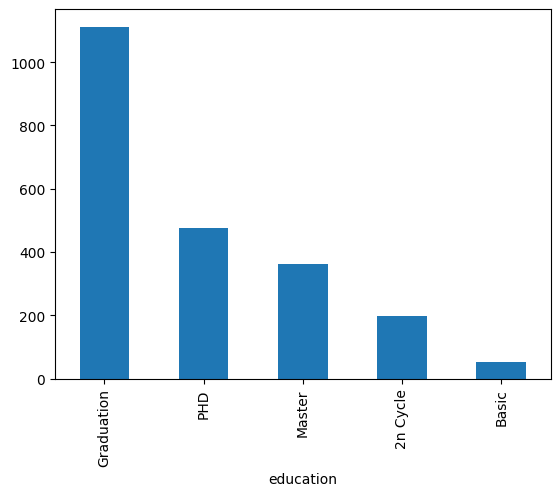

In [207]:
df['education'].value_counts().plot(kind = 'bar')

In [162]:
df['MntTotal'].sum()

np.int64(1233547)

In [163]:
#Criando coluna categoria de Idades
bins = [0, 18, 30, 50, 80]
labels = ['0-18', '19-30', '31-50', '51-80']

df['AgeRange'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [164]:
(df['AgeRange'].value_counts() / len(df) * 100).round(1)

AgeRange
31-50    49.2
51-80    48.1
19-30     2.7
0-18      0.0
Name: count, dtype: float64

In [165]:
(df.groupby(['AgeRange'])[['Income','MntTotal', 'IncomeMonth']].mean().round(0)).sort_values(by = 'MntTotal', ascending = False)

C:\Users\Support\AppData\Local\Temp\ipykernel_18800\2941186947.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df.groupby(['AgeRange'])[['Income','MntTotal', 'IncomeMonth']].mean().round(0)).sort_values(by = 'MntTotal', ascending = False)


,Income,MntTotal,IncomeMonth
AgeRange,,,
19-30,51597.0,695.0,4300.0
51-80,55835.0,631.0,4653.0
31-50,47394.0,483.0,3950.0
0-18,NaN,NaN,NaN


<Axes: xlabel='AgeRange'>

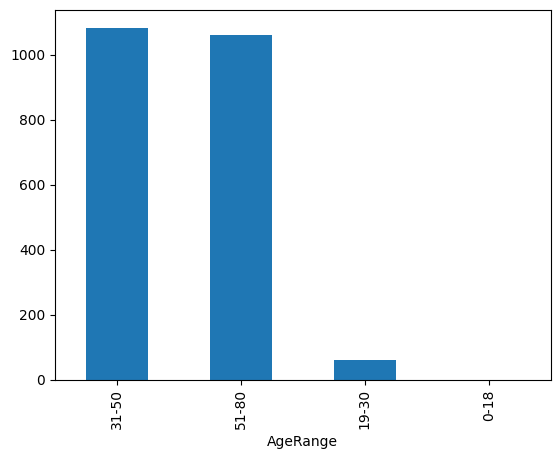

In [166]:
df['AgeRange'].value_counts().plot(kind = 'bar')

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'MntTotal'}>],
       [<Axes: title={'center': 'Income'}>, <Axes: >]], dtype=object)

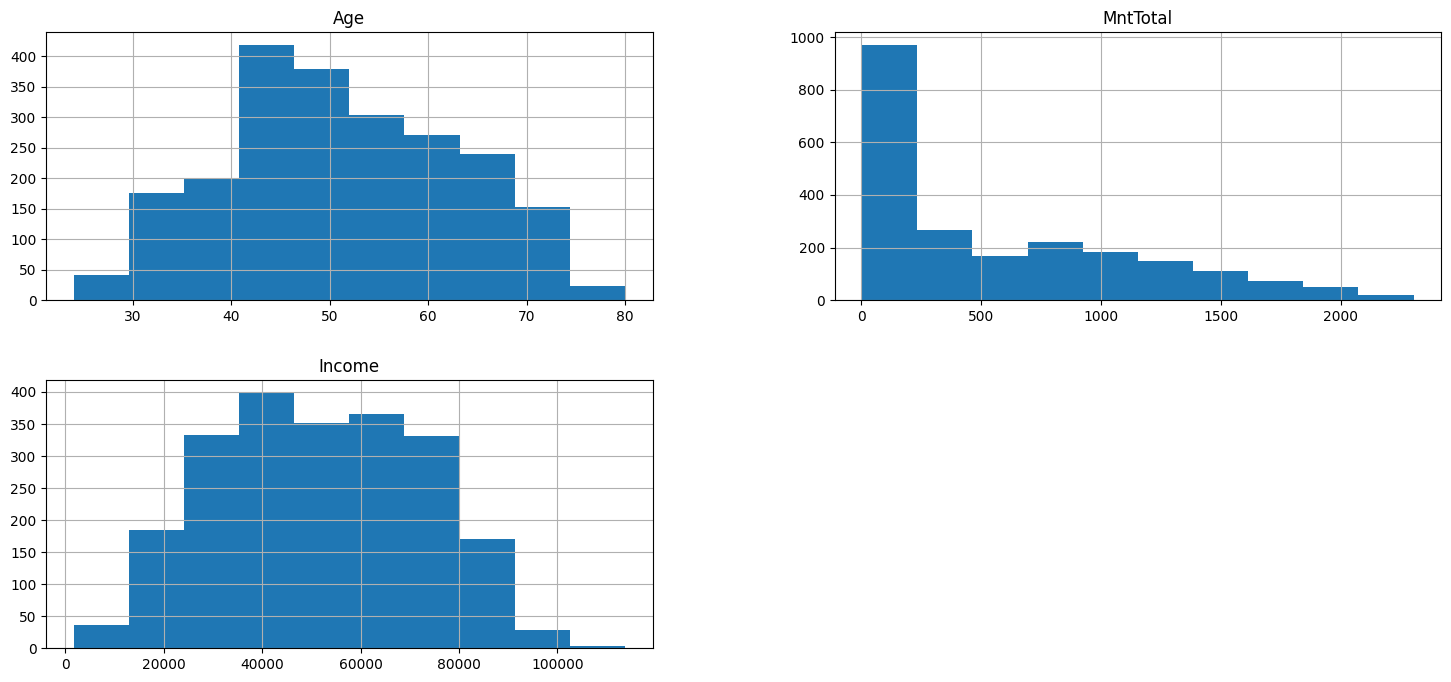

In [167]:
df.hist(column= ['Age', 'MntTotal','Income'], figsize=(18,8))

<Axes: title={'center': 'Marital Status'}, ylabel='marital_status'>

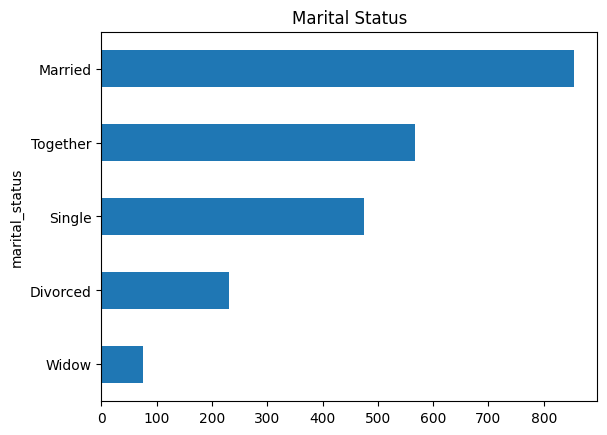

In [168]:
df['marital_status'].value_counts().sort_values().plot(kind = 'barh' , title = 'Marital Status')

In [79]:
df.iloc[:,5:12].sum().sort_values(ascending = False)

MntRegularProds     1143750
MntWines             675093
MntMeatProducts      364513
MntGoldProds          97146
MntFishProducts       83253
MntSweetProducts      59818
MntFruits             58219
dtype: int64

In [170]:
(df.iloc[:,5:12].sum().sort_values(ascending = False) / df.iloc[:,5:12].sum().sum() * 100).round(1)

MntRegularProds     46.1
MntWines            27.2
MntMeatProducts     14.7
MntGoldProds         3.9
MntFishProducts      3.4
MntSweetProducts     2.4
MntFruits            2.3
dtype: float64

<Axes: title={'center': 'Products in %'}>

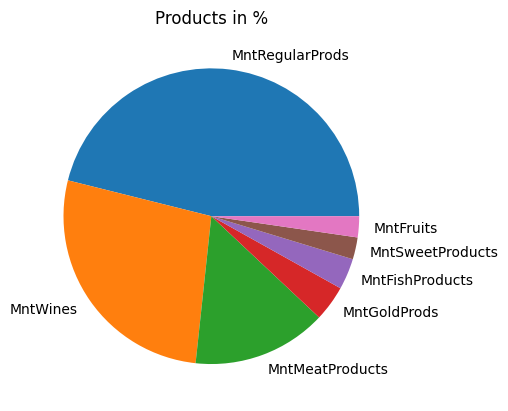

In [171]:
(df.iloc[:,5:12].sum().sort_values(ascending = False) / df.iloc[:,5:12].sum().sum() * 100).round(1).plot(kind = 'pie', title = 'Products in %')

<Axes: title={'center': 'Products'}>

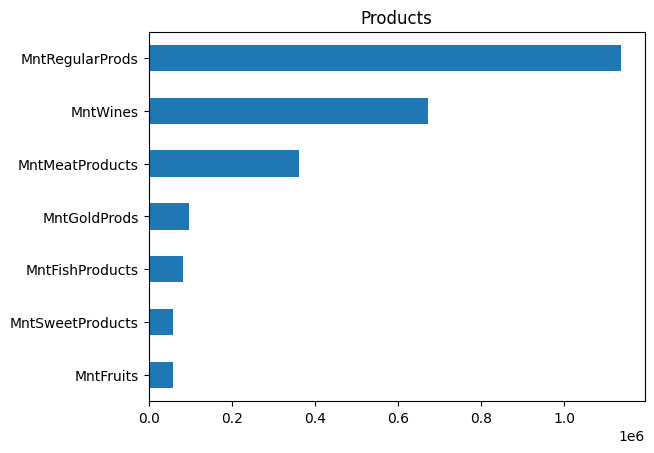

In [172]:
df.iloc[:,5:12].sum().sort_values().plot(kind = 'barh' , title="Products" )

In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2202 entries, 0 to 2204
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Index                2202 non-null   int64   
 1   Income               2202 non-null   int64   
 2   Kidhome              2202 non-null   int64   
 3   Teenhome             2202 non-null   int64   
 4   Recency              2202 non-null   int64   
 5   MntWines             2202 non-null   int64   
 6   MntFruits            2202 non-null   int64   
 7   MntMeatProducts      2202 non-null   int64   
 8   MntFishProducts      2202 non-null   int64   
 9   MntSweetProducts     2202 non-null   int64   
 10  MntRegularProds      2202 non-null   int64   
 11  MntGoldProds         2202 non-null   int64   
 12  MntTotal             2202 non-null   int64   
 13  NumDealsPurchases    2202 non-null   int64   
 14  NumWebPurchases      2202 non-null   int64   
 15  NumCatalogPurchases  2202 

<Axes: >

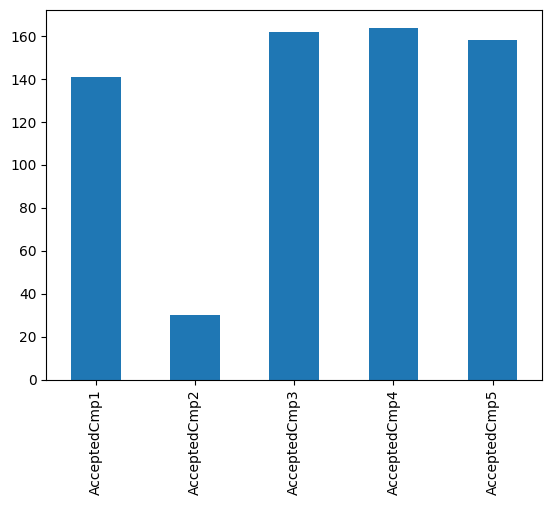

In [213]:
df.iloc[:,18:23].sum().plot(kind = 'bar')

<Axes: title={'center': 'Customer Purchase Behavior'}>

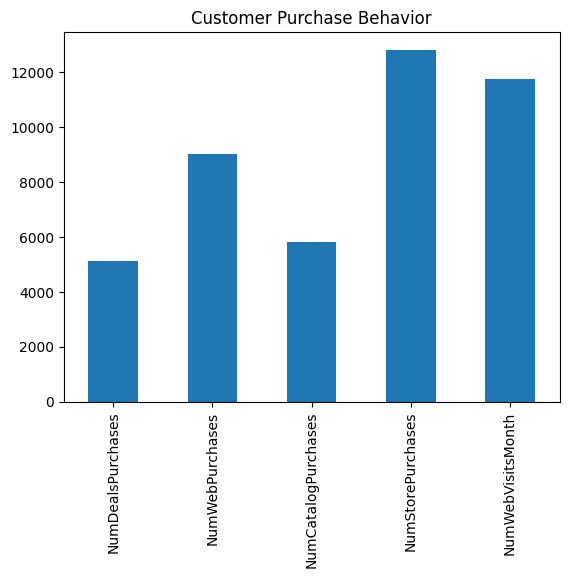

In [215]:
df.iloc[:,13:18].sum().plot(kind = 'bar' , title = 'Customer Purchase Behavior')

In [219]:
df['Complain'].value_counts(normalize=True).mul(100).round(1)

Complain
0    99.1
1     0.9
Name: proportion, dtype: float64

<Axes: title={'center': 'Complain'}, ylabel='count'>

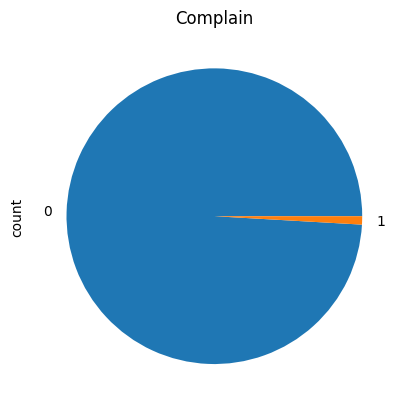

In [217]:
df['Complain'].value_counts().plot(kind = 'pie', title = 'Complain')

In [ ]:
#!pip install scikit-learn

In [95]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [204]:
# Selecionar colunas numéricas
X = df[['Age', 'Income', 'MntTotal']]

# Padronizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar kmeans
kmeans = KMeans(n_clusters=3, random_state=42)

df['cluster'] = kmeans.fit_predict(X_scaled)

print(df.head())

   Index  Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  \
0   1001   58138        0         0       58       635         88   
1   1002   46344        1         1       38        11          1   
2   1003   71613        0         0       26       426         49   
3   1004   26646        1         0       26        11          4   
4   1005   58293        1         0       94       173         43   

   MntMeatProducts  MntFishProducts  MntSweetProducts  ...  \
0              546              172                88  ...   
1                6                2                 1  ...   
2              127              111                21  ...   
3               20               10                 3  ...   
4              118               46                27  ...   

   AcceptedCmpOverall  Complain  Age  Customer_Days  marital_status  \
0                   0         0   63           2822          Single   
1                   0         0   66           2272          Single   

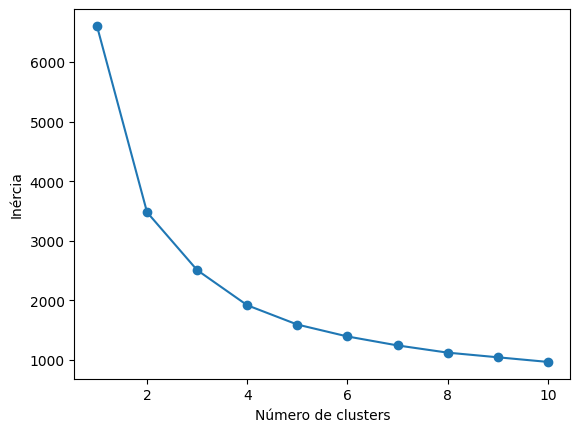

In [205]:
#Buscando o melhor 'K'
inercias = []

for k in range(1, 11):
    modelo = KMeans(n_clusters=k, random_state=42)
    modelo.fit(X_scaled)
    inercias.append(modelo.inertia_)

plt.plot(range(1, 11), inercias, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Inércia")
plt.show()

In [174]:
print(X)

      Age  Income  MntTotal
0      63   58138      1529
1      66   46344        21
2      55   71613       734
3      36   26646        48
4      39   58293       407
...   ...     ...       ...
2200   53   61223      1094
2201   74   64014       436
2202   39   56981      1217
2203   64   69245       782
2204   66   52869       151

[2202 rows x 3 columns]


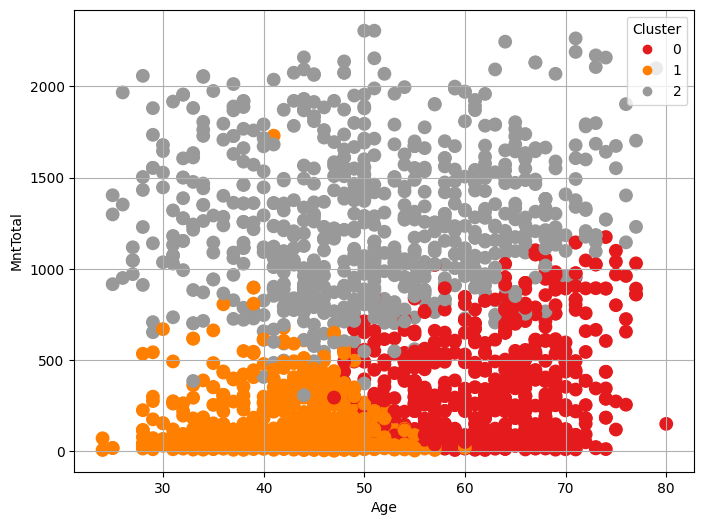

In [179]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df['Age'],
    df['MntTotal'],
    c=df['cluster'],
    cmap='Set1',
    s=80
)

plt.xlabel("Age")
plt.ylabel("MntTotal")

plt.legend(*scatter.legend_elements(), title="Cluster")

plt.grid(True)
plt.show()

In [181]:
df.groupby(['cluster'])['MntTotal'].mean().sort_values(ascending = False)

cluster
2    1245.905350
0     354.147673
1     123.115294
Name: MntTotal, dtype: float64

In [188]:
# Resumo dos clusters por MntTotal
resumo_clusters = (
    df.groupby('cluster')
    .agg(
        qtd_clientes=('cluster', 'count'),
        media_mnttotal=('MntTotal', 'mean'),
        soma_mnttotal=('MntTotal', 'sum'),
        media_income=('Income', 'mean'),
        media_age=('Age', 'mean')
    )
    .round(2)
    .sort_values(by='media_mnttotal', ascending=False)
)

resumo_clusters

,qtd_clientes,media_mnttotal,soma_mnttotal,media_income,media_age
cluster,,,,,
2,729,1245.91,908265,73675.08,50.78
0,623,354.15,220634,49935.68,62.59
1,850,123.12,104648,33810.24,43.01


In [190]:
# Identificar o cluster com maior média de MntTotal
maior_cluster_mnttotal = resumo_clusters.index[0]

print(f"Cluster com maior média de MntTotal: {maior_cluster_mnttotal}")

# Criar um DataFrame apenas com clientes desse cluster
df_maior_cluster = df[df['cluster'] == maior_cluster_mnttotal].copy()

df_maior_cluster

Cluster com maior média de MntTotal: 2


,Index,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmpOverall,Complain,Age,Customer_Days,marital_status,education,AgeRange,IncomeMonth,cluster,MntTotal_>_1k
0,1001,58138,0,0,58,635,88,546,172,88,...,0,0,63,2822,Single,Graduation,51-80,4844.833333,2,True
2,1003,71613,0,0,26,426,49,127,111,21,...,0,0,55,2471,Together,Graduation,51-80,5967.750000,2,False
5,1006,62513,0,1,16,520,42,98,0,42,...,0,0,53,2452,Together,Master,51-80,5209.416667,2,False
11,1012,63033,0,0,82,194,61,480,225,112,...,0,0,61,2385,Divorced,Graduation,51-80,5252.750000,2,True
14,1015,82800,0,0,23,1006,22,115,59,68,...,2,0,74,2741,Single,PHD,51-80,6900.000000,2,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2188,3189,75777,0,0,12,712,26,538,69,13,...,2,0,38,2519,Single,Master,31-50,6314.750000,2,True
2193,3194,63777,1,1,87,457,5,106,15,17,...,0,0,41,2621,Married,Graduation,31-50,5314.750000,2,False
2197,3198,44802,0,0,71,853,10,143,13,10,...,0,0,50,2836,Single,Master,31-50,3733.500000,2,True
2200,3201,61223,0,1,46,709,43,182,42,118,...,0,0,53,2540,Married,Graduation,51-80,5101.916667,2,True


In [195]:
# Perfil do maior cluster por MntTotal
perfil_maior_cluster = df_maior_cluster[
    ['Age', 'Income', 'IncomeMonth', 'MntTotal', 'Customer_Days']
].describe().round(2)

perfil_maior_cluster

,Age,Income,IncomeMonth,MntTotal,Customer_Days
count,729.00,729.00,729.00,729.00,729.00
mean,50.78,73675.08,6139.59,1245.91,2532.64
std,11.53,9976.08,831.34,396.62,206.96
min,25.00,44802.00,3733.50,308.00,2160.00
25%,43.00,66476.00,5539.67,948.00,2349.00
50%,50.00,73454.00,6121.17,1205.00,2558.00
75%,59.00,80685.00,6723.75,1534.00,2720.00
max,79.00,105471.00,8789.25,2304.00,2856.00


In [192]:
df_maior_cluster['AgeRange'].value_counts(normalize=True).mul(100).round(1)

AgeRange
51-80    48.6
31-50    47.6
19-30     3.8
0-18      0.0
Name: proportion, dtype: float64

In [193]:
df_maior_cluster[
    ['Index', 'Age', 'AgeRange', 'Income', 'IncomeMonth', 'MntTotal', 'marital_status', 'education']
].sort_values(by='MntTotal', ascending=False).head(10)

,Index,Age,AgeRange,Income,IncomeMonth,MntTotal,marital_status,education
967,1968,51,51-80,75759,6313.250000,2304,Married,Graduation
1433,2434,50,31-50,93790,7815.833333,2304,Single,Graduation
1032,2033,71,51-80,69098,5758.166667,2262,Married,PHD
1576,2577,64,51-80,90226,7518.833333,2244,Married,Master
1723,2724,71,51-80,80360,6696.666667,2188,Married,PHD
1966,2967,73,51-80,91712,7642.666667,2169,Single,Master
71,1072,44,31-50,75825,6318.750000,2158,Single,Graduation
1419,2420,74,51-80,82657,6888.083333,2157,Together,Graduation
1239,2240,51,51-80,76653,6387.750000,2153,Together,Graduation
1268,2269,48,31-50,83151,6929.250000,2136,Married,Master


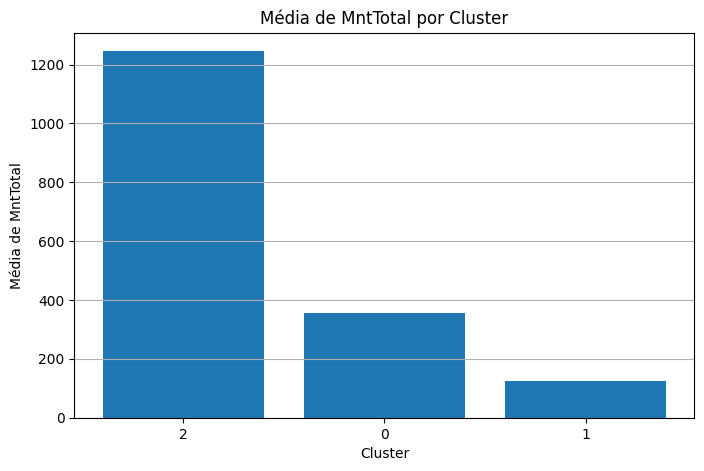

In [194]:
plt.figure(figsize=(8, 5))

plt.bar(
    resumo_clusters.index.astype(str),
    resumo_clusters['media_mnttotal']
)

plt.title('Média de MntTotal por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Média de MntTotal')
plt.grid(axis='y')
plt.show()

In [199]:
# Correlação das variáveis numéricas do maior cluster
correlacao_maior_cluster = df_maior_cluster[
    ['Age', 'Income', 'IncomeMonth', 'MntTotal', 'Customer_Days']
].corr().round(2)

correlacao_maior_cluster

,Age,Income,IncomeMonth,MntTotal,Customer_Days
Age,1.00,0.05,0.05,0.11,-0.00
Income,0.05,1.00,1.00,0.41,-0.20
IncomeMonth,0.05,1.00,1.00,0.41,-0.20
MntTotal,0.11,0.41,0.41,1.00,0.18
Customer_Days,-0.00,-0.20,-0.20,0.18,1.00


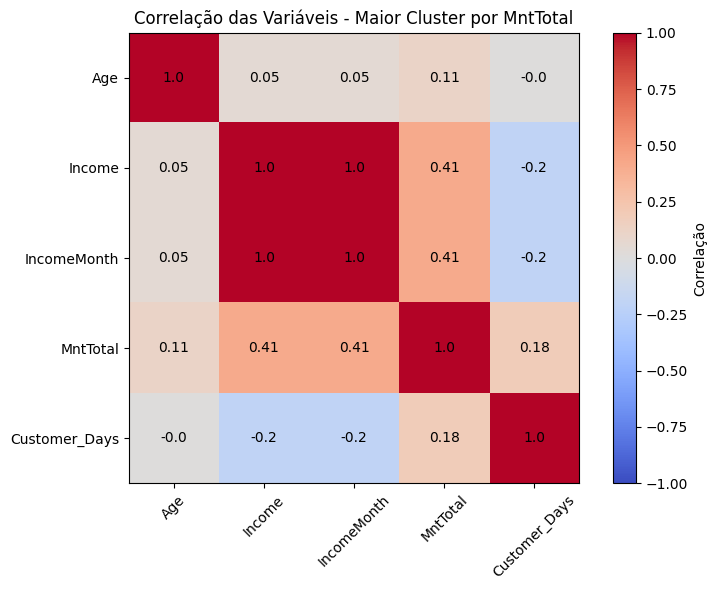

In [200]:
plt.figure(figsize=(8, 6))

plt.imshow(correlacao_maior_cluster, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlação')

plt.xticks(
    range(len(correlacao_maior_cluster.columns)),
    correlacao_maior_cluster.columns,
    rotation=45
)

plt.yticks(
    range(len(correlacao_maior_cluster.columns)),
    correlacao_maior_cluster.columns
)

# Mostrar os valores dentro dos quadrados
for i in range(len(correlacao_maior_cluster.columns)):
    for j in range(len(correlacao_maior_cluster.columns)):
        plt.text(
            j,
            i,
            correlacao_maior_cluster.iloc[i, j],
            ha='center',
            va='center',
            color='black'
        )

plt.title('Correlação das Variáveis - Maior Cluster por MntTotal')
plt.tight_layout()
plt.show()

In [201]:
correlacao_maior_cluster_todos = df_maior_cluster.select_dtypes(include='number').corr().round(2)
correlacao_maior_cluster_todos

,Index,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmpOverall,Complain,Age,Customer_Days,IncomeMonth,cluster
Index,1.00,-0.03,0.00,0.02,0.07,-0.00,0.04,0.01,0.03,-0.01,...,0.03,0.07,-0.00,0.04,0.04,0.05,-0.00,-0.01,-0.03,NaN
Income,-0.03,1.00,-0.08,-0.38,-0.00,0.09,0.16,0.45,0.18,0.22,...,-0.00,0.03,0.07,0.45,0.35,0.02,0.05,-0.20,1.00,NaN
Kidhome,0.00,-0.08,1.00,0.09,0.02,-0.04,-0.06,-0.18,-0.09,-0.09,...,-0.06,-0.02,0.03,-0.06,-0.05,0.06,-0.10,0.05,-0.08,NaN
Teenhome,0.02,-0.38,0.09,1.00,0.03,0.02,-0.20,-0.48,-0.23,-0.16,...,0.00,-0.01,0.02,-0.25,-0.18,-0.01,0.09,0.13,-0.38,NaN
Recency,0.07,-0.00,0.02,0.03,1.00,0.03,-0.05,0.05,-0.01,0.02,...,0.01,0.00,0.00,-0.01,-0.02,0.03,0.03,0.04,-0.00,NaN
MntWines,-0.00,0.09,-0.04,0.02,0.03,1.00,-0.21,-0.02,-0.21,-0.20,...,0.24,0.13,0.36,0.37,0.45,-0.03,0.15,0.22,0.09,NaN
MntFruits,0.04,0.16,-0.06,-0.20,-0.05,-0.21,1.00,0.22,0.32,0.30,...,-0.12,0.04,-0.17,-0.03,-0.08,0.01,-0.03,-0.03,0.16,NaN
MntMeatProducts,0.01,0.45,-0.18,-0.48,0.05,-0.02,0.22,1.00,0.26,0.20,...,-0.08,0.02,-0.10,0.18,0.09,0.02,0.01,0.02,0.45,NaN
MntFishProducts,0.03,0.18,-0.09,-0.23,-0.01,-0.21,0.32,0.26,1.00,0.31,...,-0.12,-0.02,-0.17,-0.06,-0.07,-0.03,0.01,-0.01,0.18,NaN
MntSweetProducts,-0.01,0.22,-0.09,-0.16,0.02,-0.20,0.30,0.20,0.31,1.00,...,-0.09,0.01,-0.12,0.04,-0.00,-0.02,-0.03,0.02,0.22,NaN


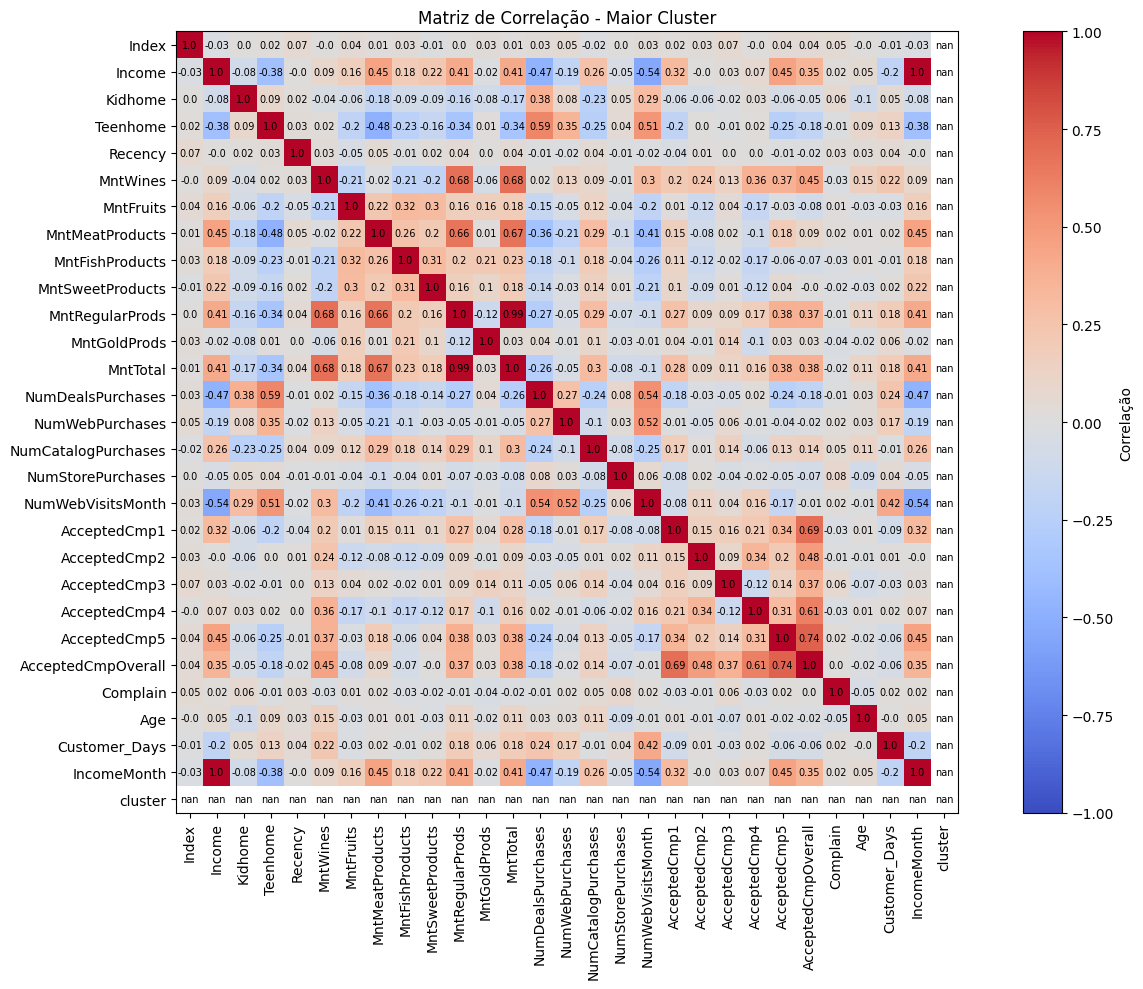

In [203]:
plt.figure(figsize=(14, 10))

plt.imshow(correlacao_maior_cluster_todos, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlação')

plt.xticks(
    range(len(correlacao_maior_cluster_todos.columns)),
    correlacao_maior_cluster_todos.columns,
    rotation=90
)

plt.yticks(
    range(len(correlacao_maior_cluster_todos.columns)),
    correlacao_maior_cluster_todos.columns
)

for i in range(len(correlacao_maior_cluster_todos.columns)):
    for j in range(len(correlacao_maior_cluster_todos.columns)):
        plt.text(
            j,
            i,
            correlacao_maior_cluster_todos.iloc[i, j],
            ha='center',
            va='center',
            fontsize=7,
            color='black'
        )

plt.title('Matriz de Correlação - Maior Cluster')
plt.tight_layout()
plt.show()

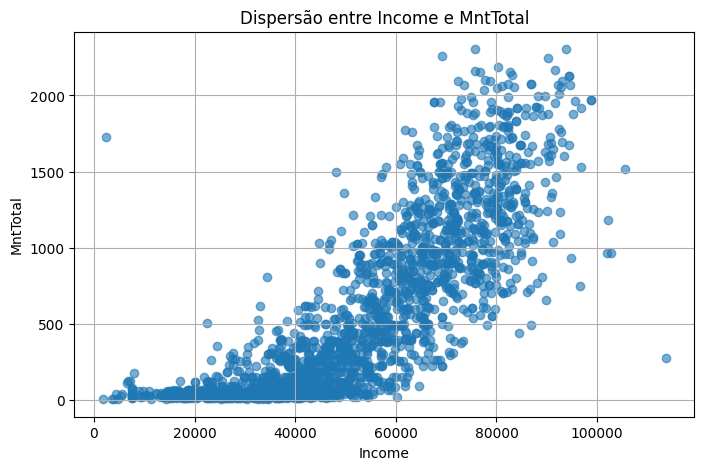

In [221]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Income'],
    df['MntTotal'],
    alpha=0.6
)

plt.title('Dispersão entre Income e MntTotal')
plt.xlabel('Income')
plt.ylabel('MntTotal')
plt.grid(True)
plt.show()

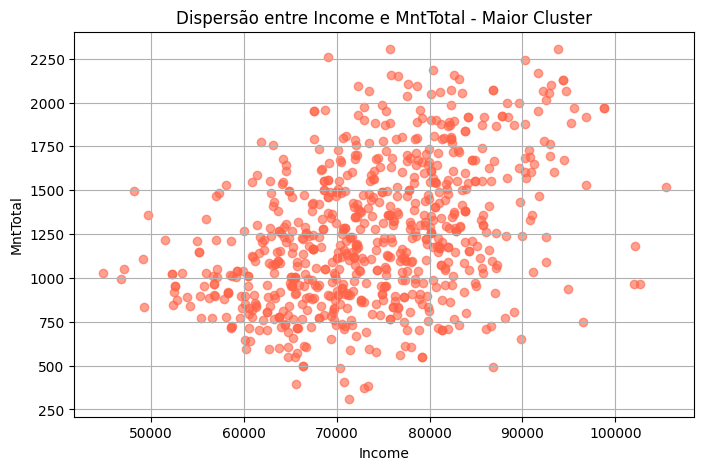

In [222]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_maior_cluster['Income'],
    df_maior_cluster['MntTotal'],
    alpha=0.6,
    color='tomato'
)

plt.title('Dispersão entre Income e MntTotal - Maior Cluster')
plt.xlabel('Income')
plt.ylabel('MntTotal')
plt.grid(True)
plt.show()